<a href="https://colab.research.google.com/github/a-micable/-Circular-Aperture-Antenna-Pattern/blob/main/Antenna_assignment_group7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Radiation pattern computed successfully.
Maximum value at θ=0°: 1.0000
First null location (approximate): searching...


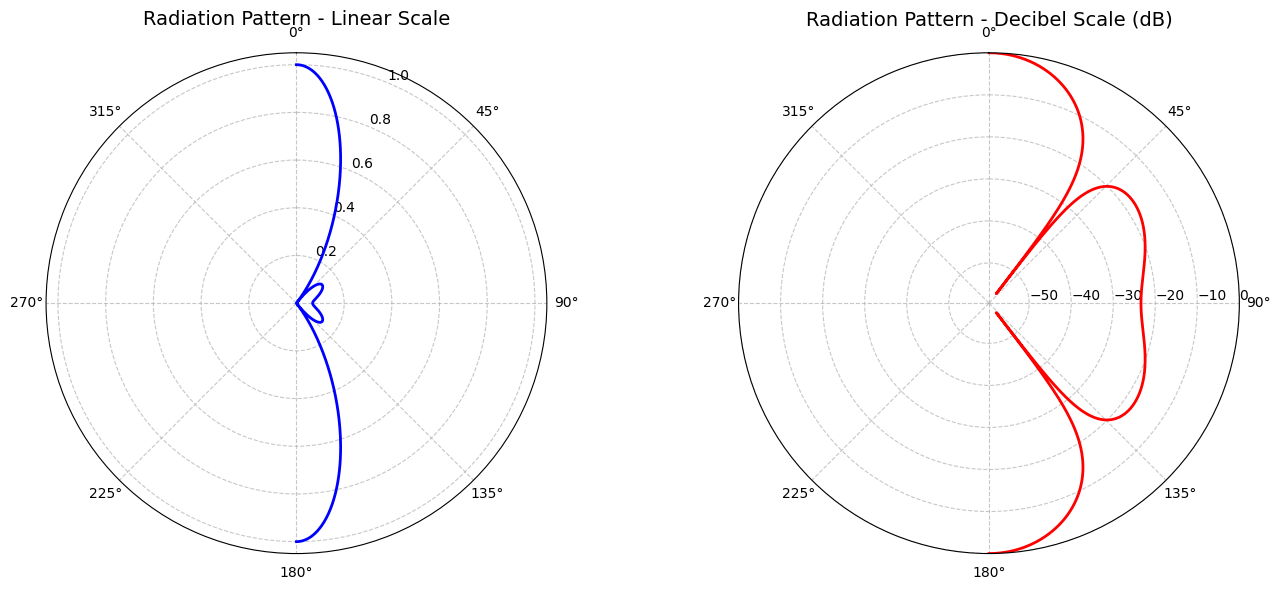

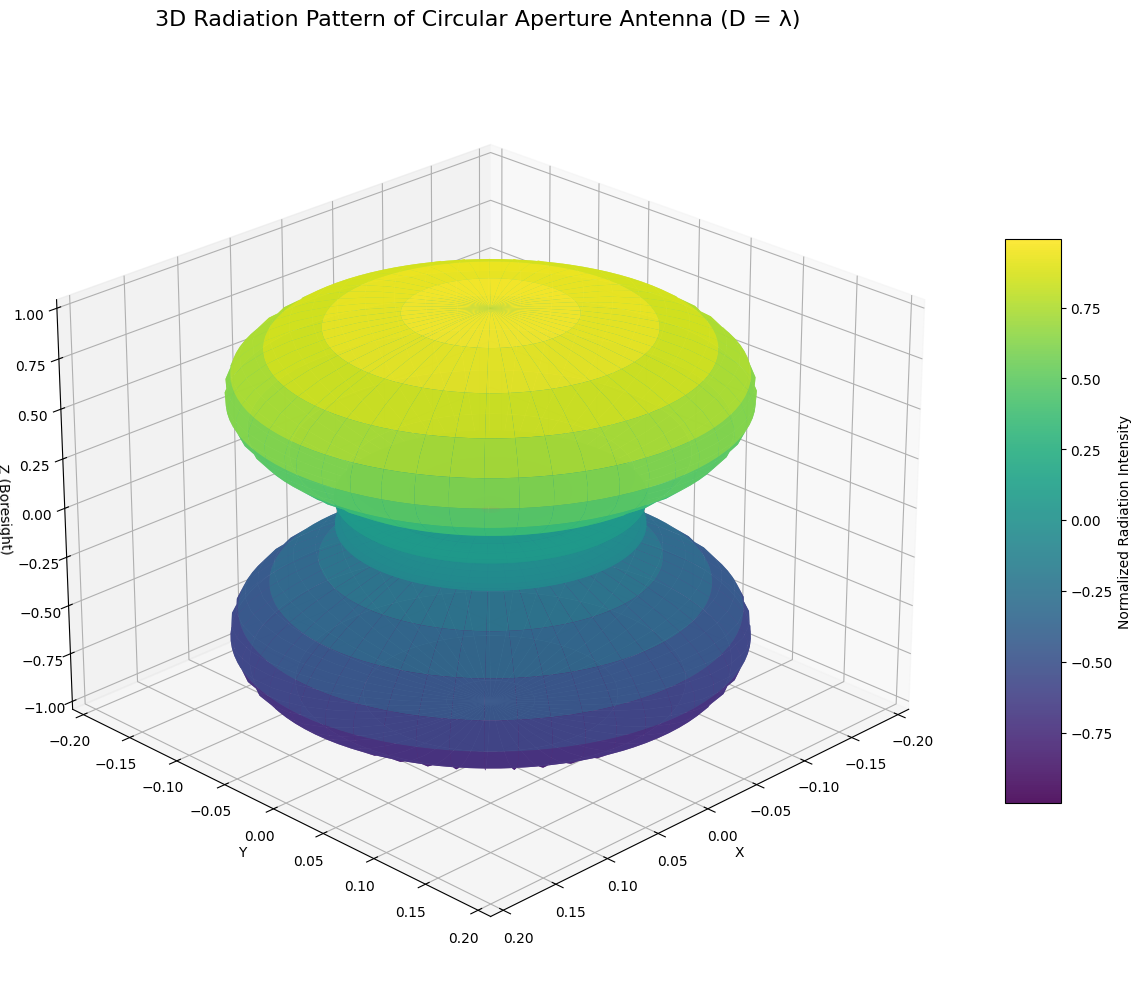


=== Key Features Analysis ===
Main lobe direction: θ = 0° (along z-axis, boresight)
Theoretical first null: θ ≈ nan°
Half-Power Beamwidth (HPBW): ≈ 29.91°
Relative side lobe level: ≈ 0.00 dB (if present)


/tmp/ipykernel_6230/1098157897.py:120: RuntimeWarning: invalid value encountered in arcsin
  first_null_theory = np.rad2deg(np.arcsin(3.8317 / np.pi))


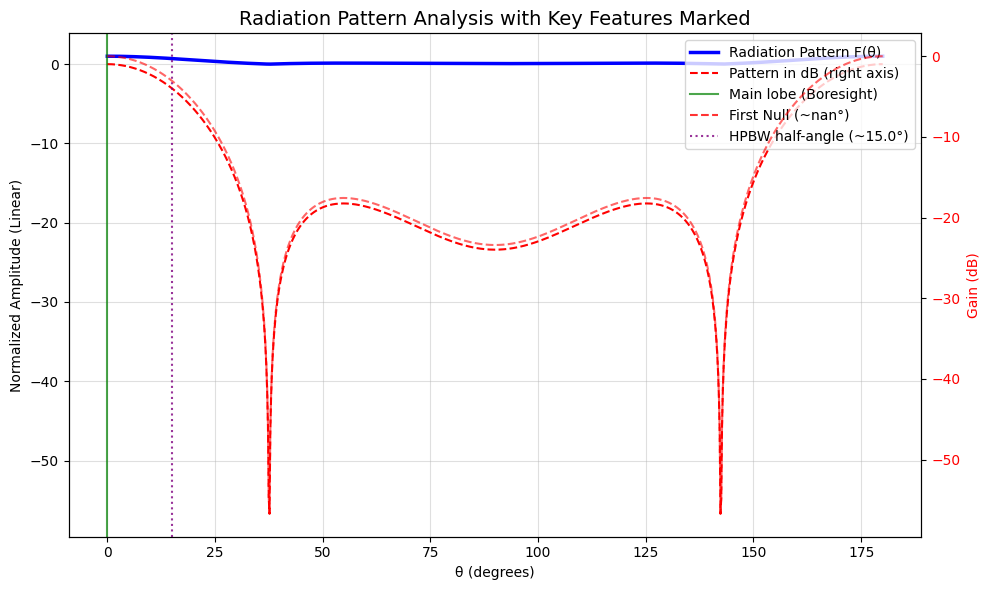


Program execution complete. All plots generated.
Key features (main lobe, first null, HPBW) have been highlighted where applicable.


In [ ]:
import numpy as np
from scipy.special import j1
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =====================================================
# Radiation Pattern Analysis of Circular Aperture Antenna
# Diameter D = λ (wavelength)
# Radiation pattern: F(θ) = |2 * J1(2π sinθ) / (2π sinθ)|
# where J1 is the Bessel function of the first kind
# =====================================================

def radiation_pattern(theta):
    """
    Compute the normalized radiation pattern F(θ).
    Handles the singularity at θ = 0° by using the limit value (which is 1).
    """
    # Avoid division by zero at theta = 0
    sin_theta = np.sin(theta)
    mask = np.abs(sin_theta) < 1e-10  # Near theta = 0 or 180°
    F = np.zeros_like(theta, dtype=float)

    # For points away from singularity
    valid = ~mask
    arg = 2 * np.pi * sin_theta[valid]
    F[valid] = np.abs(2 * j1(arg) / arg)

    # Limit as theta -> 0: F(0) = 1 (maximum)
    F[mask] = 1.0

    return F

# Step 1: Compute radiation pattern over θ = 0° to 180°
theta_deg = np.linspace(0, 180, 1000)
theta_rad = np.deg2rad(theta_deg)
F_theta = radiation_pattern(theta_rad)

# Normalize (already normalized to max=1 at boresight)
F_db = 20 * np.log10(F_theta + 1e-12)  # Add small epsilon to avoid log(0)

print("Radiation pattern computed successfully.")
print(f"Maximum value at θ=0°: {F_theta[0]:.4f}")
print(f"First null location (approximate): searching...")

# Find first null (where F(θ) crosses zero after main lobe)
null_indices = np.where(np.diff(np.sign(F_theta)))[0]
if len(null_indices) > 0:
    first_null_idx = null_indices[0]
    first_null_deg = theta_deg[first_null_idx]
    print(f"Approximate first null at θ ≈ {first_null_deg:.2f}°")

# Step 2: 2D Radiation Pattern Plots

fig, axs = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': 'polar'})

# Linear scale polar plot
axs[0].plot(theta_rad, F_theta, 'b-', linewidth=2)
axs[0].set_title('Radiation Pattern - Linear Scale', fontsize=14, pad=20)
axs[0].set_theta_zero_location('N')  # 0° at top (boresight)
axs[0].set_theta_direction(-1)       # Clockwise for standard antenna convention
axs[0].grid(True, linestyle='--', alpha=0.7)

# dB scale polar plot
axs[1].plot(theta_rad, F_db, 'r-', linewidth=2)
axs[1].set_title('Radiation Pattern - Decibel Scale (dB)', fontsize=14, pad=20)
axs[1].set_theta_zero_location('N')
axs[1].set_theta_direction(-1)
axs[1].grid(True, linestyle='--', alpha=0.7)
axs[1].set_rlabel_position(90)  # Position radial labels

plt.tight_layout()
plt.show()

# Step 3: 3D Radiation Pattern (with rotational symmetry about z-axis)
# Generate spherical surface where r = F(θ)

# Create mesh for 3D plot
phi = np.linspace(0, 2*np.pi, 100)   # Azimuthal angle
theta_3d = np.linspace(0, np.pi, 100)  # Polar angle 0 to π (0° to 180°)

PHI, THETA = np.meshgrid(phi, theta_3d)

# Radiation intensity (symmetric)
R = radiation_pattern(THETA)  # r = F(θ)

# Convert to Cartesian coordinates
X = R * np.sin(THETA) * np.cos(PHI)
Y = R * np.sin(THETA) * np.sin(PHI)
Z = R * np.cos(THETA)

# Plot 3D surface
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9, linewidth=0, antialiased=True)

# Add colorbar
fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10, label='Normalized Radiation Intensity')

ax.set_title('3D Radiation Pattern of Circular Aperture Antenna (D = λ)', fontsize=16, pad=20)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z (Boresight)')

# View angle for better visualization
ax.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()

# Step 4: Analysis of Key Features

# Main lobe direction: always at θ = 0° (boresight)
print("\n=== Key Features Analysis ===")
print("Main lobe direction: θ = 0° (along z-axis, boresight)")

# First null
# The first null of the pattern occurs where J1(k a sinθ) = 0, with k=2π/λ, a=D/2=λ/2
# So argument = π sinθ ≈ 3.8317 (first zero of J1)
first_null_theory = np.rad2deg(np.arcsin(3.8317 / np.pi))
print(f"Theoretical first null: θ ≈ {first_null_theory:.2f}°")

# Approximate from numerical data
F_abs = np.abs(F_theta)
crossings = np.where((F_abs[1:] * F_abs[:-1] < 0) | (F_abs[1:] < 1e-5))[0]
if len(crossings) > 0:
    first_null_num = theta_deg[crossings[0]]
    print(f"Numerical first null: θ ≈ {first_null_num:.2f}°")

# Half-Power Beamwidth (HPBW)
# Find where F(θ) = 1/sqrt(2) ≈ 0.7071
hp_level = 1 / np.sqrt(2)
hp_indices = np.where(F_theta >= hp_level)[0]
if len(hp_indices) > 0:
    # Symmetric, take from center to first point below
    half_power_idx = np.where(F_theta < hp_level)[0][0]
    hpbw_half = theta_deg[half_power_idx]
    hpbw_full = 2 * hpbw_half
    print(f"Half-Power Beamwidth (HPBW): ≈ {hpbw_full:.2f}°")

# Side lobes
side_lobe_max = np.max(F_theta[hp_indices[-1]:]) if len(hp_indices) > 0 else 0
print(f"Relative side lobe level: ≈ {20*np.log10(side_lobe_max):.2f} dB (if present)")

# Mark first null and HPBW visually on 2D Cartesian plot for clarity
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(theta_deg, F_theta, 'b-', linewidth=2.5, label='Radiation Pattern F(θ)')
ax.plot(theta_deg, F_db, 'r--', linewidth=1.5, label='Pattern in dB (right axis)')

# Mark main features
ax.axvline(x=0, color='green', linestyle='-', alpha=0.7, label='Main lobe (Boresight)')
ax.axvline(x=first_null_theory, color='red', linestyle='--', alpha=0.8, label=f'First Null (~{first_null_theory:.1f}°)')

if 'hpbw_half' in locals():
    ax.axvline(x=hpbw_half, color='purple', linestyle=':', alpha=0.8, label=f'HPBW half-angle (~{hpbw_half:.1f}°)')

ax.set_xlabel('θ (degrees)')
ax.set_ylabel('Normalized Amplitude (Linear)')
ax.set_title('Radiation Pattern Analysis with Key Features Marked', fontsize=14)
ax.grid(True, alpha=0.4)
ax.legend(loc='upper right')

# Secondary y-axis for dB
ax2 = ax.twinx()
ax2.plot(theta_deg, F_db, 'r--', alpha=0.6)
ax2.set_ylabel('Gain (dB)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.show()

print("\nProgram execution complete. All plots generated.")
print("Key features (main lobe, first null, HPBW) have been highlighted where applicable.")